In [135]:
import numpy as np
import xarray as xr
import pandas as pd
import re
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [149]:
slgt = False
if slgt:
    slgt_str = '_slgt'
else:
    slgt_str = ''

In [77]:
# split days into positive/negative/near zero bias (for one of 12 bias types)--can be done with just targets!
targets = xr.open_dataset(f'data/processed_data/train_targets{slgt_str}.nc')

In [78]:
sd_split = .431

variables = targets.variable.values

# Preallocate the output variable directly (same shape/coords as desired)
day_ds = xr.Dataset(
    {
        "bias_sign": (
            ("hazard", "variable", "time"),
            np.empty((len(targets.hazard), len(variables), len(targets.time)), dtype=object),
        )
    },
    coords={
        "hazard": targets.hazard,
        "variable": variables,
        "time": targets.time,
    },
)

# Fill bias_sign for each variable
for variable in variables:
    vals = targets[variable]  # shape: (hazard, time)
    day_ds["bias_sign"].loc[dict(variable=variable)] = xr.where(
        vals > sd_split,
        "pos",
        xr.where(vals < -sd_split, "neg", "zero"),
    )


In [79]:
day_ds.to_netcdf(f"data/processed_data/day_splits{slgt_str}.nc")

Making Plots

In [155]:
day_ds = xr.open_dataset(f"data/processed_data/day_splits{slgt_str}.nc")

In [160]:
# plot composite (uncentered) weather variable and outlook of given set of days function
# plot composite (centered) weather variable and outlook of given set of days function

def plot_composites(outlooks, weather, days, var_to_plot, hazard=None, centered=False):
    """
    Plot composites of either an outlook probability field or a weather variable.

    Parameters
    ----------
    outlooks : xr.Dataset
        Contains prob(time, y, x, hazard), lat(y,x), lon(y,x).
    weather : xr.Dataset
        Contains various gridded weather variables with day as a dimension.
    days : list-like
        Subset of days (datetime64 or strings) to average over.
    var_to_plot : str
        Name of the variable to composite and plot (in either `weather` or `outlooks`).
    hazard : str or None, optional
        If plotting outlook probabilities, specify which hazard ('Wind', 'Hail', etc.).
    centered : bool, optional
        If True, recenters composites on max prob location (stubbed for now).
    """

    if centered:
        # Stub for future centering logic
        raise NotImplementedError("Centered composites not implemented yet.")

    # --- 1. Handle outlooks data ---
    if var_to_plot == "prob" or var_to_plot in outlooks.data_vars:
        if hazard is None:
            raise ValueError("Must specify a hazard when plotting outlook probabilities.")

        # Select days + hazard, then average
        sub = outlooks.sel(time=days, hazard=hazard)
        comp = sub["prob"].mean(dim="time")

        lats = outlooks["lat"]
        lons = outlooks["lon"]
        title = f"Outlook Probability Composite ({hazard})"

    # --- 2. Handle weather data ---
    elif var_to_plot in weather.data_vars:
        sub = weather[var_to_plot].sel(day=days)
        comp = sub.mean(dim="day")

        # Weather lat/lon naming conventions differ
        if "latitude" in weather and "longitude" in weather:
            lats = weather["latitude"]
            lons = weather["longitude"]
        elif "lat" in weather and "lon" in weather:
            lats = weather["lat"]
            lons = weather["lon"]
        else:
            raise KeyError("Weather dataset missing lat/lon coordinates.")

        title = f"Weather Composite: {var_to_plot}"

    else:
        raise KeyError(f"Variable {var_to_plot} not found in outlooks or weather datasets.")

    # --- 3. Plot composite map ---
    fig, ax = plt.subplots(
        figsize=(9, 6),
        subplot_kw={"projection": ccrs.LambertConformal(central_longitude=-95, central_latitude=35)}
    )

    ax.set_extent([-125, -67, 25, 50], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.STATES, linewidth=0.7)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    # Use pcolormesh for plotting
    pcm = ax.pcolormesh(
        lons,
        lats,
        comp,
        cmap="coolwarm",
        transform=ccrs.PlateCarree()
    )

    plt.colorbar(pcm, ax=ax, orientation="horizontal", pad=0.05, label=var_to_plot)
    ax.set_title(title)
    plt.show()

    # TODO: make probability colors better, plot/handle level era5 variables, handle wind barbs?, handle centering, save (optionally)

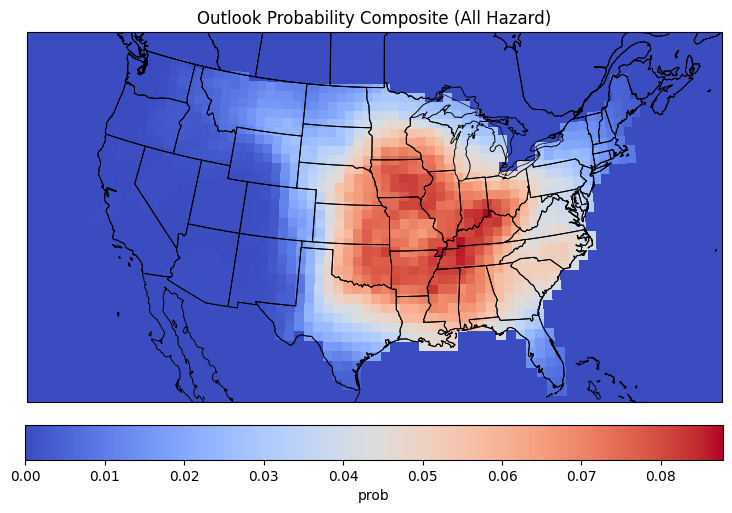

In [161]:
plot_composites(outlooks, weather, days, "prob", "All Hazard", centered=False)

In [153]:
# plot single day function

In [158]:
outlooks = xr.open_dataset('data/raw_data/outlooks.nc')
weather = xr.open_zarr('data/processed_data/train_inputs_small.zarr').load()

Hazard: Wind, Variable: north_shift, Bias Sign: pos, Number of Days: 104


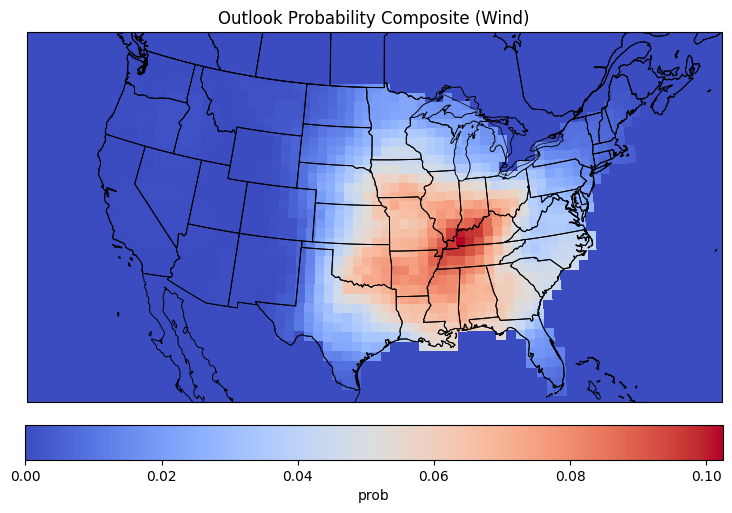

Hazard: Wind, Variable: north_shift, Bias Sign: neg, Number of Days: 114


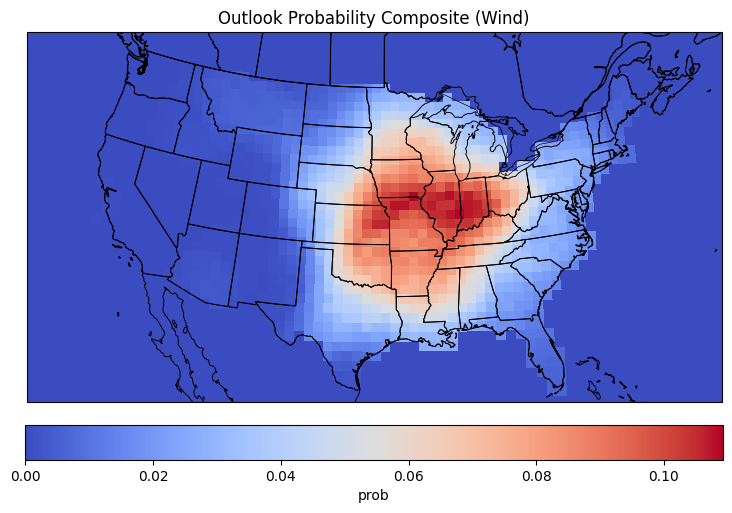

Hazard: Wind, Variable: north_shift, Bias Sign: zero, Number of Days: 114


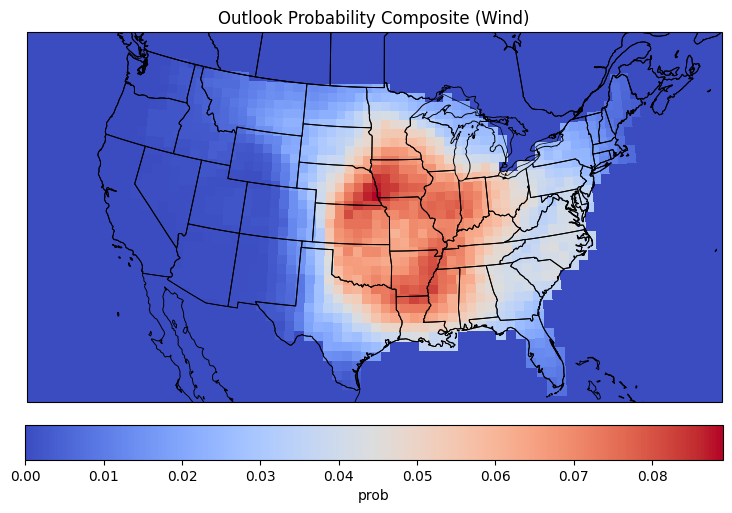

In [159]:
for hazard in day_ds.hazard.values:
    for variable in day_ds.variable.values:
        for bias_sign in ['pos', 'neg', 'zero']:
            days = day_ds['time'][(day_ds.bias_sign.sel(hazard=hazard, variable=variable) == bias_sign).values].values
            
            if len(days) > 0:
                #print(days)
                if hazard == "Wind" and variable == "north_shift":
                    print(f'Hazard: {hazard}, Variable: {variable}, Bias Sign: {bias_sign}, Number of Days: {len(days)}')
                    plot_composites(outlooks, weather, days, "prob", "Wind", centered=False)

In [ ]:
# for a specific model, for a specific target variable, break days somehow--days where model predicts positive, negative, and near zero. Or where model error is +/-/0? Then cross with true biases, and composite each of those categories.

Only run once, don't need to again:

In [90]:
# plot composites and look at examples from 
outlooks = xr.open_dataset('data/raw_data/grid_outlooks.nc')
outlooks = outlooks.assign_coords(time=pd.to_datetime(outlooks.time.astype(str), format='%Y%m%d%H%M'))

# Select Day 1 outlooks (including hazard types)
outlooks = outlooks.sel(outlook=[o for o in outlooks.outlook.values if o.startswith('Day 1')])

# Select only times in known list
outlooks = outlooks.sel(time=outlooks.time.isin(day_ds['time']))

def map_outlook_to_hazard(o):
    """Map Day 1 outlook strings to clean hazard names."""
    if o == 'Day 1':
        return 'All Hazard'
    elif re.search(r'Wind', o):
        return 'Wind'
    elif re.search(r'Hail', o):
        return 'Hail'
    elif re.search(r'Tornado', o):
        return 'Tornado'
    else:
        return None  # unexpected case

# Apply mapping
hazards = [map_outlook_to_hazard(o) for o in outlooks.outlook.values]

# Assign new coordinate
outlooks = outlooks.assign_coords(hazard=('outlook', hazards))

# Drop the old 'outlook' coordinate and rename
outlooks = outlooks.swap_dims({'outlook': 'hazard'}).drop_vars('outlook')
outlooks.to_netcdf("data/raw_data/outlooks.nc")